# Real exercises: Data Capture

Use this notebook to record exercise data at the gym: pull ups, dips, 90° push ups, front level pulls, etc. Record myself with the phone on the sagital and frontal planes to understand everything better, make sure to produce reliable stationary periods between repetitions to evaluate velocity ZUPTs and that the signal processing pipeline on the device is disabled. 

## Setup

In [1]:
# Run in case of ModuleNotFoundError:
# cd ./signal-utils
# pip install -e .

from signal_utils import IMUSampleReceiver, IMUSampleWriter
import numpy as np
import matplotlib.pyplot as plt


def plotRawData(seq: np.ndarray, f: np.ndarray, w: np.ndarray) -> None:
    if seq.size == 0:
        print("No samples available to plot")
        return

    fig, axes = plt.subplots(4, 2, figsize=(12, 8))

    lowerBoundAccel = min(np.min(f[:, 0]), np.min(f[:, 1]), np.min(f[:, 2]))
    upperBoundAccel = max(np.max(f[:, 0]), np.max(f[:, 1]), np.max(f[:, 2]))

    lowerBoundGyro = min(np.min(w[:, 0]), np.min(w[:, 1]), np.min(w[:, 2]))
    upperBoundGyro = max(np.max(w[:, 0]), np.max(w[:, 1]), np.max(w[:, 2]))

    axes[0, 0].set_title("Axis-wise specific force")
    fLabels = ["fx (m/s^2)", "fy (m/s^2)", "fz (m/s^2)"]
    for i in range(3):
        axes[i, 0].plot(seq, f[:, i], color="blue")
        axes[i, 0].set_ylabel(fLabels[i])
        axes[i, 0].set_xlabel("seq")
        axes[i, 0].set_ylim(lowerBoundAccel, upperBoundAccel)
        axes[i, 0].grid()
    axes[3, 0].plot(seq, np.linalg.norm(f, axis=1), color="blue", linestyle="--")
    axes[3, 0].set_ylabel("Euclidean norm (m/s^2)")
    axes[3, 0].set_xlabel("seq")
    axes[3, 0].grid()

    axes[0, 1].set_title("Axis-wise angular velocity")
    wLabels = ["roll (deg/s)", "pitch (deg/s)", "yaw (deg/s)"]
    for i in range(3):
        axes[i, 1].plot(seq, w[:, i], color="red")
        axes[i, 1].set_ylabel(wLabels[i])
        axes[i, 1].set_xlabel("seq")
        axes[i, 1].set_ylim(lowerBoundGyro, upperBoundGyro)
        axes[i, 1].grid()
    axes[3, 1].plot(seq, np.linalg.norm(w, axis=1), color="red", linestyle="--")
    axes[3, 1].set_ylabel("Euclidean norm (deg/s)")
    axes[3, 1].set_xlabel("seq")
    axes[3, 1].grid()

    fig.suptitle("IMU data (sensor frame)")
    plt.tight_layout()
    plt.show()

## Recording

In [2]:
RECORDING_DURATION_SECONDS = 30.0
EXPORTED_FILE_NAME = "test.csv"
# EXPORTED_FILE_NAME = "icm42688p-90-deg-push-ups-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-90-deg-push-ups-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-3.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-3.csv"
# EXPORTED_FILE_NAME = "icm42688p-fl-pulls.csv"

receiver = IMUSampleReceiver(RECORDING_DURATION_SECONDS)
writer = IMUSampleWriter()

await receiver.connect()
seq, f, w = await receiver.receive()
await receiver.disconnect()

writer.write(EXPORTED_FILE_NAME, seq, f, w)

Scanning for BLE device 'Gym-IMU' for up to 90s...
Found device: name=Gym-IMU, address=94:A9:90:6D:1C:1E
Connected to 94:A9:90:6D:1C:1E (Gym-IMU)
Subscribed to IMU notifications
Press the wearable button now to start transmission. Waiting for first sample...
Receiving samples for 30 seconds...
Notification #10, sample from batch: f: (-0.007538, 0.095819, 0.120404),  w: (0.052744, 0.004620, 0.000957),  seq: 65
Notification #20, sample from batch: f: (-0.007690, 0.108493, 0.127696),  w: (0.046929, 0.039499, 0.013195),  seq: 131
Notification #30, sample from batch: f: (0.005899, 0.100678, 0.128092),  w: (0.015552, 0.031716, 0.033080),  seq: 198
Notification #40, sample from batch: f: (-0.115215, 0.082661, 0.135413),  w: (0.178157, -7.045233, 0.600938),  seq: 265
Notification #50, sample from batch: f: (-0.064810, 0.168040, 0.122098),  w: (-0.273050, -2.467158, 6.881668),  seq: 331
Capture window completed
Unsubscribed from IMU notifications
SAMPLE LOSS ANALYSIS:
Sequence numbers: 12,19,32

## Time Series Plotting

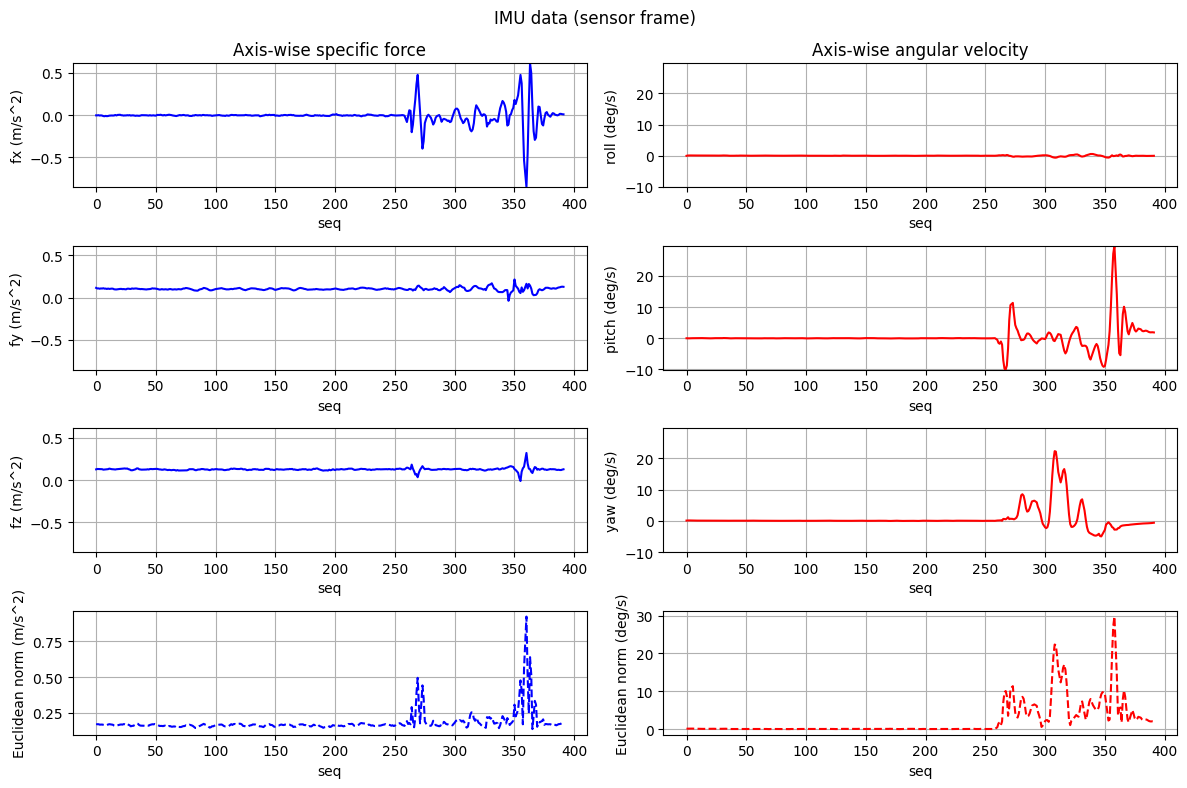

In [3]:
plotRawData(seq, f, w)